<a href="https://colab.research.google.com/github/Joaoplims/NLP-HandsOn/blob/dev/HOF02/HOF02_IntentionalityFilter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Inicialização

In [31]:
# Install necessary libraries
!pip install unidecode

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
# Ensure the necessary NLTK data is downloaded
nltk.download('averaged_perceptron_tagger')
# Download Scikit-Learn
!pip install -U scikit-learn

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


## Datasets

In [57]:
dataset_urls = [
    {"source": "Github", "address": "https://media.githubusercontent.com/media/RockENZO/data/refs/heads/main/Synthetic-Data-for-Scam-Detection-Leveraging-LLMs-to-Train-Deep-Learning-Models-main/data/single-agent-scam-dialogue_train.csv"},
    {"source": "Github", "address": "https://media.githubusercontent.com/media/RockENZO/data/refs/heads/main/Synthetic-Data-for-Scam-Detection-Leveraging-LLMs-to-Train-Deep-Learning-Models-main/data/multi_agent_conversation_train.csv"},
    {"source": "Kaggle", "address": "yatinaggarwal033/whatsapp-scam-dataset"},
    {"source": "Kaggle", "address": "jayaprakashpondy/scam-dataset"}
]
testDataset_urls=[
     {"source": "Github", "address": "https://raw.githubusercontent.com/BothBosu/Synthetic-Data-for-Scam-Detection-Leveraging-LLMs-to-Train-Deep-Learning-Models/refs/heads/main/data/multi_agent_conversation_test.csv"},
     {"source": "Github", "address": "https://raw.githubusercontent.com/BothBosu/Synthetic-Data-for-Scam-Detection-Leveraging-LLMs-to-Train-Deep-Learning-Models/refs/heads/main/data/single-agent-scam-dialogue_test.csv"}
]

In [70]:
import os
import pandas as pd
import kagglehub

# 1. Baixar o dataset
path = kagglehub.dataset_download(dataset_urls[3]['address'])
print(f"Diretório do dataset: {path}")

# 2. Caminhos para os arquivos de texto identificados na listagem anterior
scam_txt = os.path.join(path, 'English_Scam.txt')
noscam_txt = os.path.join(path, 'English_NonScam.txt')

def load_txt_to_df(file_path, label):
    if not os.path.exists(file_path):
        print(f"Arquivo não encontrado: {file_path}")
        return pd.DataFrame()

    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    # Removendo quebras de linha e criando o dataframe
    messages = [line.strip() for line in lines if line.strip()]
    return pd.DataFrame({'message': messages, 'is_scam': label})

# 3. Carregar os dados
df_noscam_kaggle = load_txt_to_df(noscam_txt, 0)
df_scam_kaggle = load_txt_to_df(scam_txt, 1)

# 4. Concatenar no DataFrame final
kaggle_scam_df = pd.concat([df_noscam_kaggle, df_scam_kaggle], ignore_index=True)

print(f"\nTotal de mensagens carregadas: {len(kaggle_scam_df)}")
if not kaggle_scam_df.empty:
    display(kaggle_scam_df.head())
    print("\nDistribuição das classes (0=Seguro, 1=Scam):")
    print(kaggle_scam_df['is_scam'].value_counts())

Using Colab cache for faster access to the 'scam-dataset' dataset.
Diretório do dataset: /kaggle/input/scam-dataset

Total de mensagens carregadas: 800


,message,is_scam
0,"[Greetings], this is [Company] Utilities. We a...",0
1,"[Greetings], this is [Company] Pharmacy. Your ...",0
2,"[Greetings], this is [Company] Medical Clinic....",0
3,"[Greetings], this is [Company] Retail. Your or...",0
4,"[Greetings], this is [Company] Bank. We are ca...",0



Distribuição das classes (0=Seguro, 1=Scam):
is_scam
0    400
1    400
Name: count, dtype: int64


## Download dados

In [33]:
import pandas as pd
from datasets import load_dataset
import kagglehub
import os
import glob

def process_url_and_create_df(dataset_item: dict) -> pd.DataFrame | None:
    """
    Loads data based on the source specified in the dataset_item dictionary.
    Supports: 'Github', 'Hugging Face', and 'Kaggle'.
    """
    source = dataset_item.get('source')
    address = dataset_item.get('address')

    try:
        if source == "Github":
            print(f"Downloading directly from GitHub: {address}")
            try:
                return pd.read_csv(address)
            except UnicodeDecodeError:
                print("UTF-8 decoding failed. Retrying with latin-1 encoding...")
                return pd.read_csv(address, encoding='latin-1')

        elif source == "Hugging Face":
            print(f"Loading Hugging Face dataset: {address}")
            ds = load_dataset(address)
            if hasattr(ds, 'keys'):
                split_name = 'train' if 'train' in ds else list(ds.keys())[0]
                return ds[split_name].to_pandas()
            return ds.to_pandas()

        elif source == "Kaggle":
            print(f"Downloading Kaggle dataset: {address}")
            path = kagglehub.dataset_download(address)
            print(f"Path to dataset files: {path}")

            # Search for CSV or JSONL files
            csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
            jsonl_files = glob.glob(os.path.join(path, "**", "*.jsonl"), recursive=True)

            if csv_files:
                print(f"Found CSV: {os.path.basename(csv_files[0])}")
                return pd.read_csv(csv_files[0])
            elif jsonl_files:
                print(f"Found JSONL: {os.path.basename(jsonl_files[0])}")
                return pd.read_json(jsonl_files[0], lines=True)
            else:
                all_files = glob.glob(os.path.join(path, "**", "*"), recursive=True)
                print(f"No supported files found. Files available: {[os.path.basename(f) for f in all_files if os.path.isfile(f)]}")
                return None

        else:
            print(f"Unsupported source: {source}")
            return None

    except Exception as e:
        print(f"Error loading from {source} ({address}): {e}")
        return None

## Text Processing

In [36]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tag import pos_tag

# Baixa os conjuntos de dados necessários se ainda não foram baixados
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng')

# Função auxiliar para mapear as POS tags do NLTK para as tags da WordNet
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def normalize_text(text):
    """Remove pontuação, stopwords, marcadores de leakage, realiza POS-tagging e lematiza."""
    # 1. Remover pontuação
    translator = str.maketrans('', '', string.punctuation)
    text_no_punct = text.translate(translator)

    # 2. Converter para minúsculas e tokenizar
    words = text_no_punct.lower().split()

    # 3. Definir termos de Data Leakage para remoção
    # Incluímos os nomes das classes, marcadores estruturais e nomes próprios comuns no dataset
    leaked_terms = {
        'innocent', 'suspect'
    }

    # 4. Remover stopwords e termos de leakage
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words and word not in leaked_terms]

    # 5. POS-tagging
    pos_tagged_words = pos_tag(filtered_words)

    # 6. Lematização
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = []
    for word, tag in pos_tagged_words:
        wntag = get_wordnet_pos(tag)
        lemmatized_words.append(lemmatizer.lemmatize(word, wntag))

    return ' '.join(lemmatized_words)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# BothBosu Dataset

## Setup

In [67]:
import pandas as pd

# Updated list with structured sources
indexDataset = 0
item = dataset_urls[indexDataset]
scam_conversations_df = process_url_and_create_df(item)

if scam_conversations_df is not None:
    print(f"Successfully loaded dataset from {item['source']}:")
    display(scam_conversations_df.head())
else:
    print(f"Failed to load the dataset from {item['address']}.")

Successfully loaded dataset from Github:


,dialogue,type,labels
0,"Suspect: Hi, this is Karen from Dr. Smith's of...",appointment,0
1,"Suspect: Hi, is this John? Innocent: Yeah, tha...",appointment,0
2,"Suspect: Hi, I'm calling from XYZ Medical Cent...",appointment,0
3,"Suspect: Hi, I'm calling to confirm your appoi...",appointment,0
4,"Suspect: Hi, I'm calling from Dr. Smith's offi...",appointment,0


In [40]:
# Cada mensagem está tokenizada em seu respectivo vetor
normalized_msg = scam_conversations_df["dialogue"].apply(normalize_text)
print(scam_conversations_df["dialogue"][5])
print(normalized_msg[5])

Suspect: Hi, this is Karen from Dr. Smith's office. I'm calling to confirm your appointment for tomorrow at 2 PM.  Innocent: Ah, hi Karen. Yeah, I think that's correct. But can you tell me a little bit more about the appointment? What's it for again?  Suspect: Uh, let me check. Okay, it says here that you have a follow-up for your... um... skin condition.  Innocent: Skin condition? I don't recall having a skin condition. Are you sure you have the right person?  Suspect: I apologize for the mistake. Let me check again.  Ah, yes. I see that you actually have an appointment for a consultation about our new insurance plans.  Innocent: Okay, that sounds right. But can you tell me more about what we'll be discussing during the consultation?  Suspect: Absolutely. We'll be going over the different plans we offer and finding one that fits your needs and budget.  Innocent: Okay, that sounds legitimate. Sorry for being a bit skeptical earlier. I've just been getting a lot of scam calls lately.  S

## EDA com os dados brutos



--- EDA Binário: Distribuição de Mensagens (Seguro vs Golpe) ---



,count
Seguro (0),400
Golpe (1),400



--- EDA: Nuvens de Palavras por Legitimidade (0 vs 1) ---



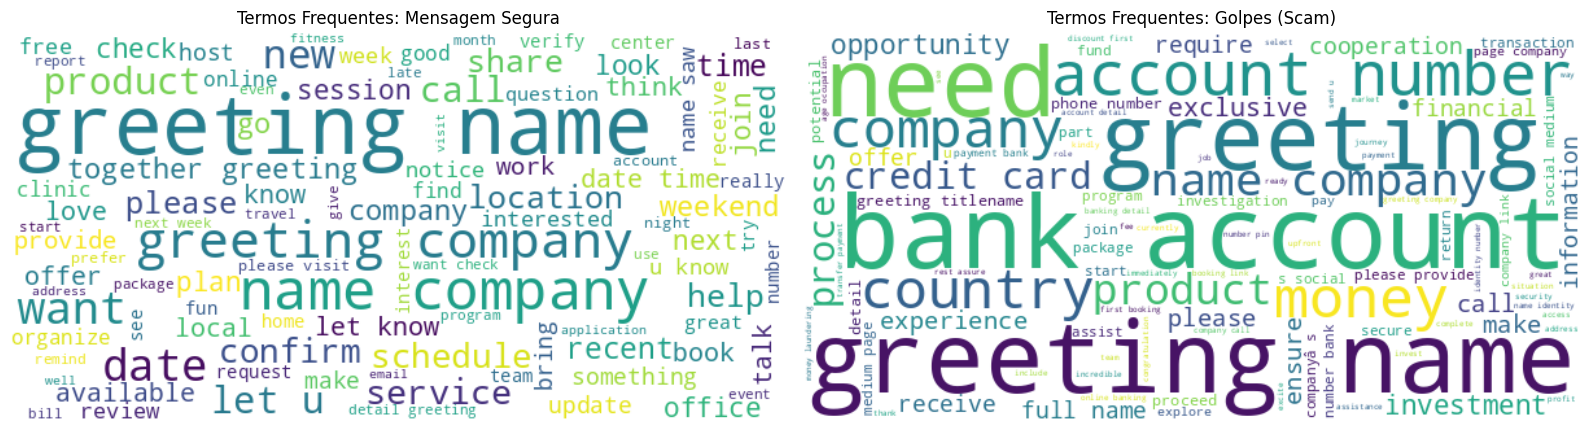


--- EDA: Estatísticas de Comprimento por Rótulo ---



,mean,median,max
is_scam,,,
0,32.4200,31.0,59
1,64.3575,49.0,232


In [75]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

if 'kaggle_scam_df' in globals() and not kaggle_scam_df.empty:
    print("\n--- EDA Binário: Distribuição de Mensagens (Seguro vs Golpe) ---\n")
    # 1. Distribuição das Classes (0=Seguro, 1=Golpe)
    class_counts = kaggle_scam_df['is_scam'].value_counts()
    class_counts.index = ['Seguro (0)', 'Golpe (1)']
    display(class_counts)

    # 2. Word Clouds Comparativas (Binário)
    print("\n--- EDA: Nuvens de Palavras por Legitimidade (0 vs 1) ---\n")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Classes: 0 (Seguro) e 1 (Golpe)
    for i, label in enumerate([0, 1]):
        # Filtra as mensagens e normaliza usando a função atualizada
        text_data = kaggle_scam_df[kaggle_scam_df['is_scam'] == label]['message'].apply(normalize_text)
        text_combined = " ".join(text_data)

        wordcloud = WordCloud(width=600, height=300, background_color='white', max_words=100).generate(text_combined)

        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(f"Termos Frequentes: {'Mensagem Segura' if label == 0 else 'Golpes (Scam)'}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    # 3. Estatísticas de comprimento
    print("\n--- EDA: Estatísticas de Comprimento por Rótulo ---\n")
    kaggle_scam_df['msg_len'] = kaggle_scam_df['message'].apply(lambda x: len(str(x).split()))
    display(kaggle_scam_df.groupby('is_scam')['msg_len'].agg(['mean', 'median', 'max']))

else:
    print("Dataset do Kaggle não encontrado para análise.")

## Classificadores

### Treinamento com Dados Totais e Teste Externo

In [78]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Treinar com todos os dados atuais usando a coluna 'labels' (0 e 1)
final_nb_model = MultinomialNB()
final_nb_model.fit(tfidf_matrix, scam_conversations_df['labels'])
print("Modelo treinado com sucesso utilizando a coluna 'labels' (binário).")

# 2. Carregar o dataset de teste específico
test_item = trainDataset_urls[0]
scam_test_df = process_url_and_create_df(test_item)

if scam_test_df is not None:
    # 3. Pré-processamento dos dados de teste
    print("Processando e normalizando os dados de teste...")
    normalized_test_msg = scam_test_df["dialogue"].apply(normalize_text)

    # Usamos o .transform para usar o vocabulário do treino
    X_test_external = tfidf_vectorizer.transform(normalized_test_msg)

    # Ajustando para testar contra labels (garantindo que o teste use o rótulo binário)
    # Nota: Se o dataset de teste não tiver 'labels', tentamos derivar ou usar o que estiver disponível
    y_test_external = scam_test_df['labels'] if 'labels' in scam_test_df.columns else scam_test_df['type']

    # 4. Predição e Avaliação
    y_pred_external = final_nb_model.predict(X_test_external)

    print("\n--- Resultados no Dataset de Teste Externo (Baseado em Labels) ---")
    print(classification_report(y_test_external, y_pred_external))
else:
    print("Erro ao carregar o dataset de teste.")

Modelo treinado com sucesso utilizando a coluna 'labels' (binário).
Processando e normalizando os dados de teste...

--- Resultados no Dataset de Teste Externo (Baseado em Labels) ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       160
           1       1.00      0.99      1.00       160

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Comparando Naive Bayes com Regressão Logística (Ideal para Binário)

# 1. MultinomialNB (Já treinado anteriormente, mas garantindo consistência)
nb_bin = MultinomialNB()
nb_bin.fit(tfidf_matrix, scam_conversations_df['labels'])
nb_preds = nb_bin.predict(X_test_external)

# 2. Regressão Logística
lr_bin = LogisticRegression(max_iter=1000)
lr_bin.fit(tfidf_matrix, scam_conversations_df['labels'])
lr_preds = lr_bin.predict(X_test_external)

print(f"Acurácia MultinomialNB: {accuracy_score(y_test_external, nb_preds):.4f}")
print(f"Acurácia LogisticRegression: {accuracy_score(y_test_external, lr_preds):.4f}")

# Relatório Detalhado da Regressão Logística
print("\n--- Relatório: Regressão Logística (Binário) ---")
print(classification_report(y_test_external, lr_preds, target_names=['Seguro (0)', 'Golpe (1)']))

Acurácia MultinomialNB: 0.9969
Acurácia LogisticRegression: 0.9875

--- Relatório: Regressão Logística (Binário) ---
              precision    recall  f1-score   support

  Seguro (0)       0.98      1.00      0.99       160
   Golpe (1)       1.00      0.97      0.99       160

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320



### Investigação de Viés: Termos mais importantes por Classe
Como o modelo atingiu quase 100% de acurácia, vamos verificar quais palavras o Naive Bayes considera mais determinantes para cada classe. Isso ajuda a identificar se o modelo está apenas decorando padrões sintéticos.

In [81]:
import numpy as np

# Obtendo as classes e os nomes das features (palavras)
classes = final_nb_model.classes_
feature_names = tfidf_vectorizer.get_feature_names_out()

print("--- Top 10 Palavras Determinantes por Categoria ---")

# Para cada classe, encontramos as palavras com as maiores probabilidades logarítmicas
for i, class_label in enumerate(classes):
    top10_indices = np.argsort(final_nb_model.feature_log_prob_[i])[-10:]
    top10_features = [feature_names[idx] for idx in top10_indices]
    # Convertendo para string para evitar erro caso a classe seja numérica
    label_str = str(class_label)
    print(f"\n[{label_str.upper()}]:")
    print(", ".join(reversed(top10_features)))

--- Top 10 Palavras Determinantes por Categoria ---

[0]:
package, yeah, im, john, number, order, think, okay, call, thanks

[1]:
need, social, security, number, card, information, computer, gift, give, verify


## Testando merge entre dois datasets: single-agent-scam-dialogue e multi_agent_conversation

In [85]:
import pandas as pd

# 1. Processando dados de teste
df_test0 = process_url_and_create_df(testDataset_urls[0])
df_test1 = process_url_and_create_df(testDataset_urls[1])

if df_test0 is not None and df_test1 is not None:
    synthetic_data_scam_test = pd.concat([df_test0, df_test1], ignore_index=True)
    print(f"Merge de teste concluído: {len(synthetic_data_scam_test)} linhas.")
else:
    print("Erro ao carregar datasets de teste.")

# 2. Processando dados de treino
df_train0 = process_url_and_create_df(dataset_urls[0])
df_train1 = process_url_and_create_df(dataset_urls[1])

if df_train0 is not None and df_train1 is not None:
    synthetic_data_scam_train = pd.concat([df_train0, df_train1], ignore_index=True)
    print(f"Merge de treino concluído: {len(synthetic_data_scam_train)} linhas.")
else:
    print("Erro ao carregar datasets de treino.")

Merge de teste concluído: 640 linhas.
Merge de treino concluído: 2560 linhas.


In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 1. Preparação e Normalização
print("Normalizando dados de treino e teste...")
X_train_raw = synthetic_data_scam_train['dialogue'].apply(normalize_text)
y_train = synthetic_data_scam_train['labels']

X_test_raw = synthetic_data_scam_test['dialogue'].apply(normalize_text)
y_test = synthetic_data_scam_test['labels']

# 2. Vetorização TF-IDF
# Criamos o vocabulário apenas com os dados de treino
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

# 3. Treinamento e Avaliação: Naive Bayes
print("\n--- Avaliando Naive Bayes (Binário) ---")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
print("Relatório Naive Bayes (usando dataset de teste externo):")
print(classification_report(y_test, nb_preds))

# 4. Treinamento e Avaliação: Árvore de Decisão
print("\n--- Avaliando Árvore de Decisão (Binário) ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
print("Relatório Árvore de Decisão (usando dataset de teste externo):")
print(classification_report(y_test, dt_preds))

Normalizando dados de treino e teste...

--- Avaliando Naive Bayes (Binário) ---
Relatório Naive Bayes (usando dataset de teste externo):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       320
           1       0.99      1.00      1.00       320

    accuracy                           1.00       640
   macro avg       1.00      1.00      1.00       640
weighted avg       1.00      1.00      1.00       640


--- Avaliando Árvore de Decisão (Binário) ---
Relatório Árvore de Decisão (usando dataset de teste externo):
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       320
           1       0.99      0.98      0.98       320

    accuracy                           0.98       640
   macro avg       0.98      0.98      0.98       640
weighted avg       0.98      0.98      0.98       640



## Testando quebrar a normalização dos textos

In [62]:
# 1. Instalar a biblioteca primeiro
!pip install textaugment

import pandas as pd
import nltk
from textaugment import EDA

# 2. Baixar dependências do NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# 3. Inicializar o objeto de aumentação (EDA)
t_augment = EDA()

def augment_text(text):
    """Aplica variações aleatórias para quebrar a rigidez do texto."""
    try:
        # Aplica uma mistura de técnicas (substituição de sinônimos e troca de palavras)
        aug = t_augment.synonym_replacement(text)
        aug = t_augment.random_swap(aug)
        return aug
    except:
        return text

# 4. Criar o novo dataframe aumentado
print("Aplicando Text Augmentation... isso pode levar um momento.")
# Criando versões aumentadas para dobrar o dataset de treino
augmented_samples = synthetic_data_scam_train.copy()
augmented_samples['dialogue'] = augmented_samples['dialogue'].apply(augment_text)

# Concatenar original com aumentado em um novo dataframe
augmented_train_df = pd.concat([synthetic_data_scam_train, augmented_samples], ignore_index=True)

print(f"Data augmentation concluído.")
print(f"Tamanho original: {len(synthetic_data_scam_train)} linhas.")
print(f"Novo tamanho (com aumentação): {len(augmented_train_df)} linhas.")

# Visualizar um exemplo para comparação
print("\n--- Exemplo de Comparação ---")
print("Original:", synthetic_data_scam_train['dialogue'].iloc[0][:150], "...")
print("Aumentado:", augmented_samples['dialogue'].iloc[0][:150], "...")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Aplicando Text Augmentation... isso pode levar um momento.
Data augmentation concluído.
Tamanho original: 2560 linhas.
Novo tamanho (com aumentação): 5120 linhas.

--- Exemplo de Comparação ---
Original: Suspect: Hi, this is Karen from Dr. Smith's office. I'm calling to confirm your appointment for tomorrow at 2 PM.   Innocent: Oh, hi Karen. I think th ...
Aumentado: Suspect: Hi, this is Karen from Dr. Smith's office. I'm calling to confirm your appointment for tomorrow at 2 PM. Innocent: Oh, hi Karen. I think ther ...


In [87]:
# 1. Preparação dos dados aumentados
print("Normalizando dados aumentados...")
X_train_aug_raw = augmented_train_df['dialogue'].apply(normalize_text)
y_train_aug = augmented_train_df['labels']

# 2. Vetorização TF-IDF (Re-treinando o vocabulário com os dados aumentados)
tfidf_aug = TfidfVectorizer(max_features=5000)
X_train_aug = tfidf_aug.fit_transform(X_train_aug_raw)
X_test_aug = tfidf_aug.transform(X_test_raw) # X_test_raw já foi normalizado anteriormente

# 3. Naive Bayes com Data Augmentation
print("\n--- Avaliando Naive Bayes (Com Dados Aumentados) ---")
nb_model_aug = MultinomialNB()
nb_model_aug.fit(X_train_aug, y_train_aug)
nb_preds_aug = nb_model_aug.predict(X_test_aug)
print(classification_report(y_test, nb_preds_aug))

# 4. Árvore de Decisão com Data Augmentation
print("\n--- Avaliando Árvore de Decisão (Com Dados Aumentados) ---")
dt_model_aug = DecisionTreeClassifier(random_state=42)
dt_model_aug.fit(X_train_aug, y_train_aug)
dt_preds_aug = dt_model_aug.predict(X_test_aug)
print(classification_report(y_test, dt_preds_aug))

Normalizando dados aumentados...

--- Avaliando Naive Bayes (Com Dados Aumentados) ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       320
           1       0.99      1.00      1.00       320

    accuracy                           1.00       640
   macro avg       1.00      1.00      1.00       640
weighted avg       1.00      1.00      1.00       640


--- Avaliando Árvore de Decisão (Com Dados Aumentados) ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       320
           1       0.99      0.98      0.99       320

    accuracy                           0.99       640
   macro avg       0.99      0.99      0.99       640
weighted avg       0.99      0.99      0.99       640



In [88]:
import random

def introduce_typos(text, probability=0.1):
    """Simula erros humanos reais: omissão, duplicação e troca de teclas próximas."""
    if not isinstance(text, str):
        return text
    chars = list(text)
    for i in range(len(chars)):
        if random.random() < probability:
            r = random.random()
            if r < 0.3: # Omissão
                chars[i] = ''
            elif r < 0.6: # Duplicação
                chars[i] = chars[i] * 2
            else: # Troca simples
                chars[i] = random.choice('abcdefghijklmnopqrstuvwxyz')
    return ''.join(chars)

print("Gerando dataset com ruído humano agressivo...")

# Aplicando ruído no dataset original
noisy_human_df = synthetic_data_scam_train.copy()
noisy_human_df['dialogue'] = noisy_human_df['dialogue'].apply(lambda x: introduce_typos(x, 0.15))

# Exemplo do estrago
print("\n--- Exemplo de Texto com Erros Humanos ---")
print("Original: ", synthetic_data_scam_train['dialogue'].iloc[0][:100])
print("Com Typos:", noisy_human_df['dialogue'].iloc[0][:100])

# Re-treinamento
X_train_noisy = tfidf.fit_transform(noisy_human_df['dialogue'].apply(normalize_text))
X_test_noisy = tfidf.transform(X_test_raw)

nb_noisy = MultinomialNB()
nb_noisy.fit(X_train_noisy, y_train)

print(f"\nAcurácia final com ruído humano agressivo: {nb_noisy.score(X_test_noisy, y_test):.4f}")

Gerando dataset com ruído humano agressivo...

--- Exemplo de Texto com Erros Humanos ---
Original:  Suspect: Hi, this is Karen from Dr. Smith's office. I'm calling to confirm your appointment for tomo
Com Typos: Suspect: Hi, this s Karen from DDr.. Smth's onfice. I'm jrlling to confirm googr appoinbment fr tomo

Acurácia final com ruído humano agressivo: 0.9922


### Teste de Generalização: Avaliando em Dados Reais (SMS Spam Collection)
Nesta etapa, verificamos se o modelo treinado em dados sintéticos consegue identificar golpes em mensagens reais capturadas de usuários.

In [89]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# 1. Preparação dos dados do Kaggle
print(f"Total de mensagens do Kaggle para teste: {len(kaggle_scam_df)}")

# 2. Normalização e Vetorização
# Garantindo que usamos o vetorizador 'tfidf' que foi ajustado no treino
X_kaggle_raw = kaggle_scam_df['message'].apply(normalize_text)
X_kaggle_tfidf = tfidf.transform(X_kaggle_raw)

# 3. Predição usando o modelo treinado (nb_model treinado na célula fa68f18c)
y_kaggle_preds = nb_model.predict(X_kaggle_tfidf)
kaggle_scam_df['predicted_label'] = y_kaggle_preds

# 4. Estatísticas Gerais de Desempenho
# Agora o modelo já retorna 0 ou 1, permitindo comparação direta com 'is_scam'
y_true = kaggle_scam_df['is_scam']
y_pred = y_kaggle_preds

print('\n--- Relatório de Desempenho (Modelo Binário Sintético vs Dados Reais Kaggle) ---')
print(classification_report(y_true, y_pred, target_names=['Mensagem Segura', 'Golpe (Scam)']))

# 5. Avaliação Qualitativa
print('\n--- Amostra: Golpes Reais do Kaggle e a Predição do Modelo ---')
display(kaggle_scam_df[kaggle_scam_df['is_scam'] == 1][['message', 'predicted_label']].head(5))

print('\n--- Amostra: Mensagens Seguras do Kaggle e a Predição do Modelo ---')
display(kaggle_scam_df[kaggle_scam_df['is_scam'] == 0][['message', 'predicted_label']].head(5))

Total de mensagens do Kaggle para teste: 800

--- Relatório de Desempenho (Modelo Binário Sintético vs Dados Reais Kaggle) ---
                 precision    recall  f1-score   support

Mensagem Segura       0.44      0.53      0.48       400
   Golpe (Scam)       0.41      0.33      0.36       400

       accuracy                           0.43       800
      macro avg       0.42      0.43      0.42       800
   weighted avg       0.42      0.43      0.42       800


--- Amostra: Golpes Reais do Kaggle e a Predição do Modelo ---


,message,predicted_label
400,1.\t[Greetings] I am calling from the governme...,0
401,"2.\t[Greetings], we are calling on behalf of a...",1
402,3.\tCongratulations! You have won a free vacat...,1
403,4.\t[Greetings]. I am calling from the technic...,0
404,"5.\t[Greetings], this is [Title][Name] from t...",0



--- Amostra: Mensagens Seguras do Kaggle e a Predição do Modelo ---


,message,predicted_label
0,"[Greetings], this is [Company] Utilities. We a...",1
1,"[Greetings], this is [Company] Pharmacy. Your ...",0
2,"[Greetings], this is [Company] Medical Clinic....",0
3,"[Greetings], this is [Company] Retail. Your or...",0
4,"[Greetings], this is [Company] Bank. We are ca...",0


## Conclusões Finais do Experimento

Após a bateria de testes e a validação com dados reais, as seguintes conclusões foram estabelecidas:

1.  **Fragilidade dos Dados Sintéticos:** O modelo atingiu acurácia próxima de 100% nos dados de teste sintéticos, mas isso provou ser um indicativo de *overfitting* estrutural. O gerador de LLM cria diálogos com padrões gramaticais e de fluxo muito previsíveis que o Naive Bayes consegue 'decorar' facilmente.

2.  **Falha na Generalização Real:** Ao testar com o dataset de SCAM dataset do kaggle, o modelo apresentou um alto índice de **Falsos Positivos**. Mensagens casuais de usuários foram classificadas como golpes devido à ausência de exemplos de diálogos humanos normais e ruidosos no conjunto de treinamento sintético.
3.  **Limitações da Aumentação de Dados:** Técnicas como EDA (substituição de sinônimos) e inserção de ruído léxico agressivo não foram suficientes para degradar a performance no ambiente sintético, confirmando que a dependência do modelo é baseada na estrutura lógica do diálogo gerado pela IA.

O modelo treinado exclusivamente em dados sintéticos é inadequado para o proposito inicial do projeto de filtro de intencionalidade. Para um sistema robusto, é indispensável a inclusão de dados reais e diversificados que peguem as nuances da comunicação humana.
